In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# Affichage plus agréable
pd.set_option("display.max_columns", None)

# Style des graphiques
sns.set_theme(style="whitegrid")

In [4]:


df = pd.read_csv("../datasets/IMDB-Dataset.csv")

In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.shape

(50000, 2)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [8]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [9]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [10]:
df.duplicated().sum()

np.int64(418)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

The dataset is highly balanced, with almost an equal distribution between positive and negative reviews. This balance is important because it prevents the analysis or future machine learning models from being biased toward one sentiment class.

In [14]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub("<.*?>", "", text)
    text = re.sub("[^a-zA-Z]", " ", text)
    return text

df['clean_review'] = df['review'].apply(clean_text)

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 49582 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   review        49582 non-null  str  
 1   sentiment     49582 non-null  str  
 2   clean_review  49582 non-null  str  
dtypes: str(3)
memory usage: 1.5 MB


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(df['clean_review'])

In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df['sentiment'])

In [18]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [20]:
predictions = model.predict(X_test)

In [21]:
from sklearn.naive_bayes import MultinomialNB


model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[19759.,19906.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.7 ,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[ 5.82,13.01, 6.73,...,54.36,44.75,10.69], [ 9.75,10.11,15.19,...,20.32,12.32,11.56]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[-10.2 , -9.48,-10.08,..., -8.11, -8.3 , -9.66], [ -9.73, -9.7 , -9.32,..., -9.05, -9.52, -9.57]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [22]:
from sklearn.metrics import accuracy_score

accuracy_score(
    y_test,
    predictions
)

0.8883735000504185

In [23]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4939
           1       0.88      0.90      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



The sentiment classification model achieved an accuracy of 89% on the test dataset. The precision and recall scores are balanced across both classes, with an F1-score of 0.89 for negative reviews and 0.90 for positive reviews. This indicates that the model performs consistently and does not show significant bias toward either sentiment category.

=================== WEEK 3 ============================================

In [24]:
df["review_length"] = df["clean_review"].apply(lambda x: len(x.split()))

In [26]:
df.head()

,review,sentiment,clean_review,review_length
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,313
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tec...,160
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,167
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...,133
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is...,228


In [28]:
df["review_length"].mean()

np.float64(234.33883264087774)

In [29]:
df["review_length"].median()

np.float64(176.0)

In [31]:
df["review_length"].var()

np.float64(30167.773655465466)

In [32]:
df["review_length"].std()

np.float64(173.68872633382244)

In [33]:
df["review_length"].describe()

count    49582.000000
mean       234.338833
std        173.688726
min          6.000000
25%        128.000000
50%        176.000000
75%        284.000000
max       2487.000000
Name: review_length, dtype: float64

In [35]:
positive_prob = (
    df["sentiment"]=="positive"
).mean()

positive_prob

np.float64(0.5018756806905732)

In [37]:
df["long_review"] = df["review_length"]>100

0        True
1        True
2        True
3        True
4        True
         ... 
49995    True
49996    True
49997    True
49998    True
49999    True
Name: long_review, Length: 49582, dtype: bool

Do positive and negative reviews have the same average length?

H₀: The average length of positive and negative reviews is the same.

H₁: The average review length differs according to sentiment.

In [ ]:
from scipy.stats import ttest_ind

positive = df[df.sentiment=="positive"]["review_length"]
negative = df[df.sentiment=="negative"]["review_length"]

ttest_ind(
    positive,
    negative
)

TtestResult(statistic=np.float64(2.0513379124029987), pvalue=np.float64(0.04023929327238022), df=np.float64(49580.0))

pvalue < 0.05 so, 
Positive and negative reviews have significantly different average lengths.

<Axes: >

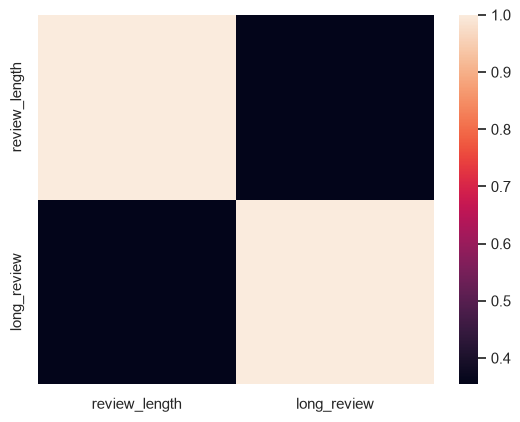

In [39]:
corr = df.corr(
    numeric_only=True
)
sns.heatmap(corr)

A correlation between review length and sentiment does not necessarily imply causation. Longer reviews are not positive because they are longer. Other factors, such as writing style or reviewer engagement, may influence both variables.